# Market Basket Analysis — EDA & Association Rule Mining

**Unsupervised association-rule mining** on the UCI *Online Retail* dataset.

> There is **no train/test split** and **no accuracy metric** — this is descriptive
> pattern mining. We rank rules `{A} → {B}` by **support, confidence, and lift** and
> translate the strongest into business actions.

This notebook reuses the reusable code in `../src/` (`preprocess.py`, `mining.py`) so the
logic matches the Streamlit app exactly. Interactive demo: `app/streamlit_app.py`.

## 0. Setup (paths, imports, data bootstrap)

In [1]:
%matplotlib inline
import os, sys, time, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# run from the project root regardless of where the kernel starts
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

# ensure the raw data exists (download from UCI on a fresh clone)
os.makedirs("data", exist_ok=True)
RAW_CSV, XLSX = "data/online_retail_raw.csv", "data/Online Retail.xlsx"
if not os.path.exists(RAW_CSV):
    if not os.path.exists(XLSX):
        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
        print("downloading raw data (~23 MB) ..."); urllib.request.urlretrieve(url, XLSX)
    pd.read_excel(XLSX).to_csv(RAW_CSV, index=False)

sys.path.insert(0, "src")
from preprocess import load_raw, clean, build_basket_matrix, format_report
from mining import frequent_itemsets, generate_rules
from mlxtend.frequent_patterns import association_rules
print("setup ok — cwd:", os.getcwd())

setup ok — cwd: /Users/mohitpatle/Library/CloudStorage/OneDrive-RelianceFoundationInstitutionofEducationandResearch/Market Basket Analysis


## 1. Data acquisition & raw columns

Grain: **one row = one product line on one invoice** (LONG format). A basket (invoice)
spans multiple rows — we pivot to WIDE later.

In [2]:
df = load_raw()
print("shape:", df.shape)
display(df.head())
print("\ndtypes:\n", df.dtypes)
print("\nnulls (%):\n", (df.isna().mean()*100).round(2))

shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



dtypes:
 InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

nulls (%):
 InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64


Three dtype "gotchas" worth knowing: `InvoiceNo` is a **string** (returns start with `C`),
`StockCode` is **alphanumeric**, and `CustomerID` is a **float** only because numpy ints
can't hold `NaN` (~25% are missing).

## 2. EDA — basket sizes, popular items, junk

count    25900.00
mean        20.51
std         42.50
min          1.00
25%          2.00
50%         10.00
75%         23.00
max       1110.00
Name: StockCode, dtype: float64
single-item baskets: 22.8%


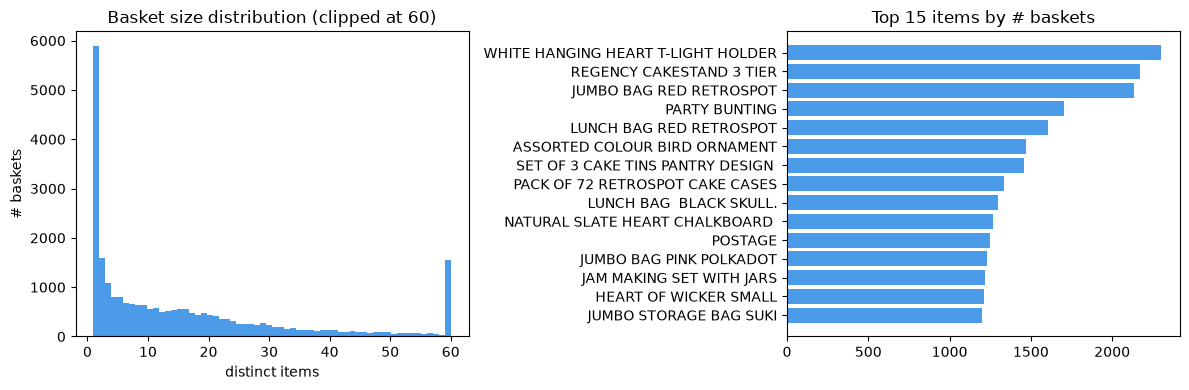

In [3]:
basket_size = df.groupby("InvoiceNo")["StockCode"].nunique()
print(basket_size.describe().round(2))
print("single-item baskets: {:.1f}%".format((basket_size==1).mean()*100))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(basket_size.clip(upper=60), bins=60, color="#4C9BE8")
ax[0].set(title="Basket size distribution (clipped at 60)", xlabel="distinct items", ylabel="# baskets")

top = df.groupby("Description")["InvoiceNo"].nunique().sort_values().tail(15)
ax[1].barh(top.index, top.values, color="#4C9BE8")
ax[1].set(title="Top 15 items by # baskets")
plt.tight_layout(); plt.show()

In [4]:
# quantify the junk we will remove (each as % of rows)
import re
N = len(df)
checks = {
    "returns (Quantity<=0)": df["Quantity"]<=0,
    "missing CustomerID": df["CustomerID"].isna(),
    "UnitPrice<=0": df["UnitPrice"]<=0,
    "blank Description": df["Description"].isna(),
    "non-product StockCode": ~df["StockCode"].astype(str).str.match(r"^\d{5}[A-Za-z]*$"),
}
pd.DataFrame({k: [int(v.sum()), round(v.mean()*100,2)] for k,v in checks.items()},
             index=["rows","pct"]).T

,rows,pct
returns (Quantity<=0),10624.0,1.96
missing CustomerID,135080.0,24.93
UnitPrice<=0,2517.0,0.46
blank Description,1454.0,0.27
non-product StockCode,2995.0,0.55


`POSTAGE` is the 11th most frequent "item" — a non-product that would co-occur with
everything and generate garbage high-confidence rules. It must go (Stage 4).

## 3. Cleaning & preprocessing

Remove only rows that are invalid **as a product purchase**. We **keep** missing
CustomerIDs (baskets group by `InvoiceNo`, never by customer) and **keep all countries**.

In [5]:
clean_df, report = clean(df)
print(format_report(report, df, clean_df))

step                              removed    remaining
start                                   0      541,909
drop blank Description              1,454      540,455
drop empty-after-normalize              0      540,455
drop Quantity <= 0 (returns)        9,762      530,693
drop UnitPrice <= 0                   589      530,104
drop non-product StockCode          2,379      527,725
--------------------------------------------------------
rows      : 541,909 -> 527,725  (kept 97.4%)
invoices  : 25,900 -> 19,773
products  : 4,223 -> 3,986 (by Description)


## 4. Basket matrix (LONG → WIDE)

The riskiest step. We build a **boolean** one-hot matrix (presence, **not** quantity) and
verify it with an independent cross-check.

In [6]:
basket = build_basket_matrix(clean_df)
print("matrix:", basket.shape, "| dtype bool:", (basket.dtypes==bool).all())
density = basket.values.mean()
print(f"density: {density*100:.2f}%  ->  {(1-density)*100:.2f}% zeros")
print(f"memory: {basket.memory_usage(deep=True).sum()/1e6:.1f} MB (bool)")

# cross-check: total True cells == unique (invoice, item) pairs
assert basket.values.sum() == clean_df[["InvoiceNo","Description"]].drop_duplicates().shape[0]
print("cross-check passed ✓")

matrix: (19773, 3986) | dtype bool: True
density: 0.66%  ->  99.34% zeros
memory: 79.9 MB (bool)


cross-check passed ✓


## 5. Mining — Apriori vs FP-Growth

Both return the **same** frequent itemsets; only runtime differs. FP-Growth builds an
FP-tree once (no candidate generation), so it pulls ahead as `min_support` drops.

,min_support,itemsets,apriori_s,fpgrowth_s,speedup,identical
0,0.03,142,0.447,0.229,2.0,True
1,0.02,384,2.100,0.451,4.7,True
2,0.01,1892,21.211,1.209,17.5,True


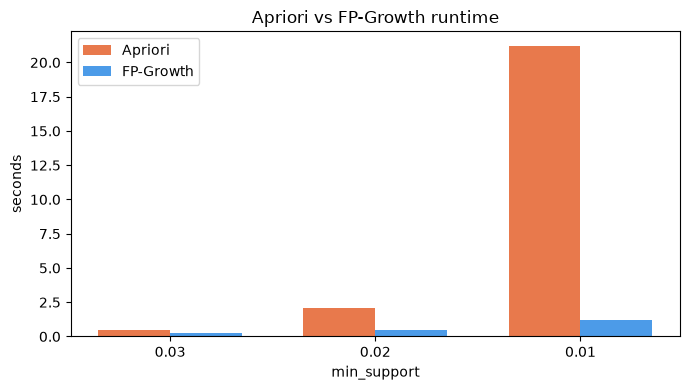

In [7]:
rows = []
for ms in [0.03, 0.02, 0.01]:
    its_a, ta = frequent_itemsets(basket, "apriori", ms)
    its_f, tf = frequent_itemsets(basket, "fpgrowth", ms)
    same = len(its_a) == len(its_f)
    rows.append({"min_support": ms, "itemsets": len(its_f),
                 "apriori_s": round(ta,3), "fpgrowth_s": round(tf,3),
                 "speedup": round(ta/tf,1), "identical": same})
runtime = pd.DataFrame(rows); display(runtime)

x = np.arange(len(runtime)); w = 0.35
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(x-w/2, runtime["apriori_s"], w, label="Apriori", color="#E8794C")
ax.bar(x+w/2, runtime["fpgrowth_s"], w, label="FP-Growth", color="#4C9BE8")
ax.set_xticks(x); ax.set_xticklabels(runtime["min_support"]); ax.set_xlabel("min_support")
ax.set_ylabel("seconds"); ax.set_title("Apriori vs FP-Growth runtime"); ax.legend()
plt.tight_layout(); plt.show()

## 6. Association rules — support, confidence, lift

We mine at `support ≥ 0.01`, then generate rules gated at `confidence ≥ 0.1`, sorted by lift.

In [8]:
itemsets, _ = frequent_itemsets(basket, "fpgrowth", min_support=0.01)
rules = generate_rules(itemsets, min_confidence=0.1, sort_by="lift")
print(f"{len(rules):,} rules | min lift = {rules['lift'].min():.2f} (all positive associations)")

def as_str(fs): return " | ".join(sorted(fs))
top = rules.head(8).assign(
    antecedents=lambda d: d["antecedents"].map(as_str),
    consequents=lambda d: d["consequents"].map(as_str))
display(top[["antecedents","consequents","support","confidence","lift"]].round(3))

3,288 rules | min lift = 1.36 (all positive associations)


,antecedents,consequents,support,confidence,lift
0,HERB MARKER THYME,HERB MARKER PARSLEY | HERB MARKER ROSEMARY,0.01,0.857,78.774
1,HERB MARKER PARSLEY | HERB MARKER ROSEMARY,HERB MARKER THYME,0.01,0.944,78.774
2,HERB MARKER PARSLEY | HERB MARKER THYME,HERB MARKER ROSEMARY,0.01,0.953,78.520
3,HERB MARKER ROSEMARY,HERB MARKER PARSLEY | HERB MARKER THYME,0.01,0.846,78.520
4,HERB MARKER BASIL | HERB MARKER THYME,HERB MARKER ROSEMARY,0.01,0.952,78.464
5,HERB MARKER ROSEMARY,HERB MARKER BASIL | HERB MARKER THYME,0.01,0.833,78.464
6,HERB MARKER BASIL | HERB MARKER ROSEMARY,HERB MARKER THYME,0.01,0.935,77.972
7,HERB MARKER THYME,HERB MARKER BASIL | HERB MARKER ROSEMARY,0.01,0.844,77.972


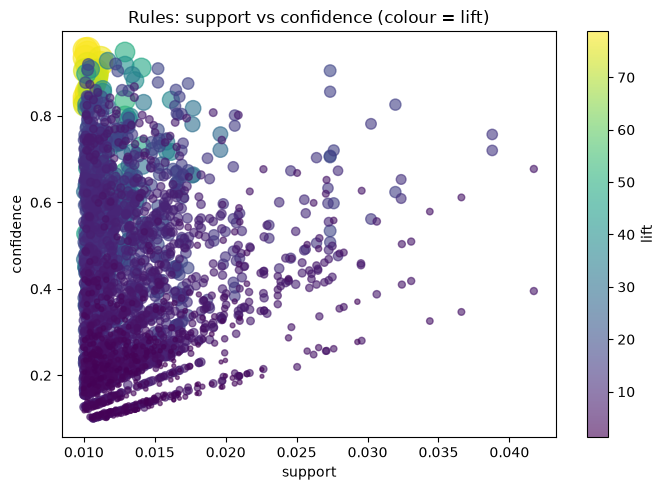

In [9]:
# support vs confidence, colour/size = lift (mirrors the app)
fig, ax = plt.subplots(figsize=(7,5))
sc = ax.scatter(rules["support"], rules["confidence"], c=rules["lift"],
                s=rules["lift"]*4, cmap="viridis", alpha=0.6)
ax.set(xlabel="support", ylabel="confidence", title="Rules: support vs confidence (colour = lift)")
plt.colorbar(sc, label="lift"); plt.tight_layout(); plt.show()

**The "everyone buys bananas" trap.** Confidence alone is fooled by popular consequents:
a rule to a best-seller can have decent confidence yet `lift ≈ 1` (no real link). `lift =
confidence / support(B)` divides out the baseline. In our clean pool every rule already has
`lift ≥ 1.36`, so the near-independent junk (and `POSTAGE`) is gone.

## 7. Interpretation — rules → business actions

Rank by **leverage** (frequency × strength) for the biggest absolute impact.

In [10]:
lev = rules.sort_values("leverage", ascending=False).head(8).assign(
    antecedents=lambda d: d["antecedents"].map(as_str),
    consequents=lambda d: d["consequents"].map(as_str))
display(lev[["antecedents","consequents","support","confidence","lift","leverage"]].round(4))

,antecedents,consequents,support,confidence,lift,leverage
674,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.0388,0.7202,14.0575,0.0360
675,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.0388,0.7572,14.0575,0.0360
2307,JUMBO BAG PINK POLKADOT,JUMBO BAG RED RETROSPOT,0.0417,0.6773,6.4112,0.0352
2308,JUMBO BAG RED RETROSPOT,JUMBO BAG PINK POLKADOT,0.0417,0.3949,6.4112,0.0352
2440,JUMBO STORAGE BAG SUKI,JUMBO BAG RED RETROSPOT,0.0366,0.6115,5.7879,0.0303
2439,JUMBO BAG RED RETROSPOT,JUMBO STORAGE BAG SUKI,0.0366,0.3466,5.7879,0.0303
440,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.0320,0.8261,16.1257,0.0300
441,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.0320,0.6239,16.1257,0.0300


**Actions**

1. **"Complete the collection" bundles** — matched sets (herb markers, Regency teacups) have very high lift.
2. **Directional cross-sell** — recommend by *confidence* (e.g. RED RETROSPOT to PINK POLKADOT buyers, 68%), not by lift.
3. **Catalog / shelf adjacency** — co-locate high-leverage pairs.
4. **Coordinated inventory** — a stockout of one variant in a set strands demand for the rest.

*Association ≠ causation — each action is a hypothesis to A/B test.*

▶️ Explore all 3,288 rules interactively in the Streamlit app: `streamlit run app/streamlit_app.py`